# AI-Powered Real-Time Customer Support Coaching Assistant

**College Project Notebook**

This notebook builds an AI assistant that listens to a customer support conversation and gives the support agent live coaching suggestions on how to respond.

---

The notebook runs in three sections, in this order:

| Section | Steps | What it does |
|---|---|---|
| **Setup** | 1-3 | Installs the libraries, takes your API key, loads the models. |
| **Part 1** | 4-18 | The coach built from small, free Hugging Face models. |
| **Part 2** | 19-24 | The same coach rebuilt on one Gemini model, and the two compared. |

### How to use this notebook

1. Open this file in **Google Colab**.
2. Run the cells **one at a time, from top to bottom** (click the play button on each cell, or press `Shift + Enter`).
3. Every step lives in its own cell with comments explaining what it does.
4. Part 1 runs without an API key. Part 2 needs one — the Gemini API has a free tier, and Step 2 explains how to get it. With a key present, Part 1's knowledge base quietly upgrades itself from keyword matching to semantic search, which costs a few calls.

> Tip: If something breaks, re-run the cells above it before re-running the failing one.


In [ ]:
# ===== Step 1: Install the libraries and set up the helpers =====

# transformers = Hugging Face library that gives us ready-made AI models
# torch        = the deep learning engine that actually runs those models
# google-genai = the official SDK for the Gemini API, used in Part 2
# --quiet      = hides the long installation log so the output stays readable
#
# BOTH halves of the notebook are installed here in one go. pip resolves
# everything in a single pass, which is quicker than installing twice, and it
# means no cell further down ever has to stop and install something.
!pip install transformers torch google-genai --quiet


# ---- Part 1 imports (Hugging Face) ----
# "pipeline" is a helper that wraps a model so we can use it in a single line.
from transformers import pipeline

# ---- Part 2 imports (Gemini API) ----
import os
import re
import json
import time

from datetime import datetime, timedelta

from dataclasses import dataclass, field
from typing import List, Optional

from google import genai
from google.genai import types

# ---- A helper both Step 2 and Step 20 need ----
# It lives HERE, in the cell nothing can work without, so it is always defined
# even if you skip Step 2 or jump straight to Part 2 after a kernel restart.

# File names we accept for the key file, tried in this order.
KEY_FILE_NAMES = [
    "gemini_api_key.txt",
    "gemini api key.txt",
    "gemini_key.txt",
    "api_key.txt",
    ".env",
]

# If none of those exact names exist, any .txt file whose name contains these
# word pairs counts too, so a slightly differently named file is still found.
# Matching ignores upper/lower case.
KEY_FILE_WORDS = [("gemini", "key"), ("api", "key")]


def key_file_folders():
    """Every folder we are willing to look in for the key file."""

    folders = []

    def add(folder):
        if folder and os.path.isdir(folder) and folder not in folders:
            folders.append(folder)

    # 1. Wherever this kernel was started, plus a few folders above it. This
    #    is what catches "I started Jupyter from the wrong directory".
    here = os.getcwd()
    add(here)

    parent = here
    for _ in range(3):
        parent = os.path.dirname(parent)
        add(parent)

    # 2. VS Code tells the notebook its own path in this variable, so we can
    #    look next to the .ipynb file itself even if the kernel started
    #    somewhere else entirely.
    notebook_path = globals().get("__vsc_ipynb_file__")
    if notebook_path:
        add(os.path.dirname(notebook_path))

    # 3. Where Colab puts uploaded files, and mounted Google Drive.
    add("/content")
    add("/content/drive/MyDrive")

    # 4. Home and Downloads, for a key file kept outside the project folder.
    home = os.path.expanduser("~")
    add(home)
    add(os.path.join(home, "Downloads"))

    return folders


def find_key_file():
    """Return the path of the first key file we can find, or ""."""

    folders = key_file_folders()

    # Exact names first, in every folder.
    for folder in folders:
        for file_name in KEY_FILE_NAMES:
            path = os.path.join(folder, file_name)
            if os.path.isfile(path):
                return path

    # Then the loose match. We skip home and Downloads here on purpose -- a
    # search that broad could pick up an unrelated file.
    for folder in folders[:4]:

        try:
            entries = sorted(os.listdir(folder))
        except OSError:
            continue          # no permission to read this folder

        for entry in entries:

            lowered = entry.lower()

            if not lowered.endswith(".txt"):
                continue

            for first_word, second_word in KEY_FILE_WORDS:
                if first_word in lowered and second_word in lowered:
                    path = os.path.join(folder, entry)
                    if os.path.isfile(path):
                        return path

    return ""


def read_key_file():
    """Read GEMINI_API_KEY out of a local key file. Returns "" if not found."""

    path = find_key_file()

    if path:

        with open(path) as key_file:
            for line in key_file:

                line = line.strip()

                # Skip blank lines and the "# ..." instructions in the file.
                if not line or line.startswith("#"):
                    continue

                if "=" in line:
                    # A "GEMINI_API_KEY=..." line.
                    name, _, value = line.partition("=")
                    if name.strip() == "GEMINI_API_KEY":
                        value = value.strip().strip("\"'")
                        if value:
                            return value
                else:
                    # A file holding nothing but the key itself.
                    return line.strip("\"'")

    return ""


def get_gemini_api_key(prompt_if_missing=True):
    """Find the Gemini API key. Returns "" if we could not get one.

    Looks in four places, in order, and remembers whatever it finds so the
    rest of the notebook can just read the environment variable.
    """

    # 1. Already in the environment? Then we are done.
    key = os.getenv("GEMINI_API_KEY", "").strip()

    # 2. A key file next to the notebook -- the easiest option, because you
    #    edit it once and never see a prompt again.
    if not key:
        key = read_key_file()

    # 3. On Colab: the Secrets panel (key icon in the left sidebar). Add a
    #    secret named GEMINI_API_KEY and switch "Notebook access" on.
    if not key:
        try:
            from google.colab import userdata
            key = (userdata.get("GEMINI_API_KEY") or "").strip()
        except Exception:
            key = ""

    # 4. Otherwise, type it in. getpass hides what you type, so the key never
    #    appears in the notebook output.
    #    HEADS UP: in VS Code the input box appears at the TOP of the window,
    #    not next to the cell. It is easy to miss and dismiss by accident.
    if not key and prompt_if_missing:
        from getpass import getpass
        key = getpass("Paste your Gemini API key: ").strip()

    if key:
        os.environ["GEMINI_API_KEY"] = key

    return key


print("All libraries installed and imported.")


All libraries installed and imported.


In [ ]:
# ===== Step 2: Give the notebook your Gemini API key =====

# GET A KEY (free, no credit card):
#   1. Open  https://aistudio.google.com/apikey
#   2. Sign in with a Google account -> "Create API key"
#   3. Copy it. The free tier is rate-limited (a few requests per minute),
#      not credit-limited, so it does not run out.
#
# Part 2 needs this key. Part 1 does not -- but it will USE one if it is
# here: Step 14's knowledge base prefers semantic search when a key is
# available, and falls back to keyword matching when it is not.
#
# WHERE TO PUT IT -- easiest first:
#   A. Open the file  gemini_api_key.txt  next to this notebook, paste your
#      key after "GEMINI_API_KEY=", and save. Nothing else to do.
#      (On Colab, upload that file too, or use option B instead.)
#   B. On Colab: the Secrets panel (key icon, left sidebar). Add a secret
#      named GEMINI_API_KEY and turn "Notebook access" on.
#   C. Do nothing, and type the key into the prompt when asked.
#
# The key is NEVER written inside the notebook, so the .ipynb can be shared
# without leaking it. Just do not share gemini_api_key.txt itself.
# get_gemini_api_key() was defined in Step 1.

# We ask now, so a missing key shows up here in two seconds rather than after
# a 2 GB model download in Step 3.
api_key = get_gemini_api_key()

if api_key:
    print("Gemini API key is set. Part 2 is ready to run.")

    # Say WHICH file it came from, so there is never any doubt about which
    # copy of the key is actually in use.
    found_file = find_key_file()
    if found_file:
        print(f"Read from: {found_file}")
else:
    # Deliberately a warning, NOT an error. Part 1 (Steps 3-18) is completely
    # free and needs no key, so a missing key must not stop the notebook here.
    # Step 20 asks again at the moment the key is actually needed.
    print("No Gemini API key yet.")
    print("Part 1 (Steps 3-18) will run fine without one -- its knowledge")
    print("base falls back to keyword matching.")
    print("Part 2 will ask you again when it needs it.")
    print()
    print("Looked for a key file in these folders:")
    for folder in key_file_folders():
        print("   ", folder)


Gemini API key is set. Part 2 is ready to run.


In [ ]:
# ===== Step 3: Load the Part 1 AI models =====

# NOTE: The first time you run this cell, Hugging Face DOWNLOADS these
# pre-trained models from the internet and caches them in Colab. The first run
# is slow (about 1.1 GB for the sentiment model and 1.6 GB for the intent
# model) and every run after that is fast. You do NOT have to train anything
# yourself -- these models already know how to do their job.

# Model 1: Sentiment analysis -> tells us whether the customer sounds
# POSITIVE, NEUTRAL or NEGATIVE, so the agent knows when someone is upset.
#
# We name the model explicitly instead of letting transformers pick its default
# English-only one, because our customers write in Hinglish (Hindi + English
# mixed together). "xlm-roberta" is a MULTILINGUAL model, so it was trained on
# many languages instead of English alone.
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment"
)

# Model 2: Zero-shot classification -> guesses the customer's intent using
# category labels that WE choose later, with no extra training needed.
intent_classifier = pipeline("zero-shot-classification")


# IMPORTANT: this multilingual model does not answer the same way the old
# English-only model did. It has THREE moods instead of two (negative /
# neutral / positive), it writes them in lowercase, and some versions of it
# reply with codes like "LABEL_0" instead of words.
# This small helper cleans all of that up, so the rest of the notebook can
# always rely on getting a tidy uppercase label back.
def normalize_sentiment(raw_result):
    """Turn the model's raw answer into NEGATIVE, NEUTRAL or POSITIVE."""
    label = raw_result[0]["label"].upper()
    label_codes = {"LABEL_0": "NEGATIVE", "LABEL_1": "NEUTRAL", "LABEL_2": "POSITIVE"}
    return label_codes.get(label, label)


print("Models loaded and ready!")


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.11GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Models loaded and ready!


In [ ]:
# ===== Step 4: Test the sentiment analyzer on one customer message =====

# This is the message we pretend a customer just sent to our support agent.
customer_message = "I am very much disappointed with your service."

# Feed the message to the model. It reads the text and decides the mood.
result = sentiment_analyzer(customer_message)

# The model gives back a LIST containing one DICTIONARY, like this:
#   [{'label': 'negative', 'score': 0.87}]
#   'label' -> negative, neutral or positive (the mood the model detected)
#   'score' -> how confident it is, from 0.0 to 1.0 (0.87 = 87% sure)
# It is a list because you can pass in many messages at once and get one
# dictionary back for each of them.
print(result)

# The label arrives in lowercase, so we run it through our helper from Step 3
# to get the tidy uppercase version the rest of the notebook expects.
print("Cleaned label:", normalize_sentiment(result))

[{'label': 'negative', 'score': 0.9329906702041626}]
Cleaned label: NEGATIVE


In [ ]:
# ===== Step 5: Detect WHAT the customer wants (intent detection) =====

# Sentiment told us HOW the customer feels. Intent tells us WHAT they need.
# These are the categories we want the model to choose from. They are just
# plain English words -- we can edit this list any time without retraining.
intents = ["complaint", "query", "purchase", "technical issue", "feedback"]

# "Zero-shot" means the model was never trained on OUR specific categories.
# We hand it the message plus our list, and it scores how well each label fits.
intent_result = intent_classifier(customer_message, intents)

# The model returns a DICTIONARY with three keys:
#   'sequence' -> the original message we sent in
#   'labels'   -> our intents, REORDERED from most likely to least likely
#   'scores'   -> the matching confidence for each label, in the same order
#
# IMPORTANT: 'labels' comes back SORTED BEST-FIRST. It is NOT in the order we
# wrote them above. So position [0] is always the model's top choice, [1] is
# the runner-up, and so on.
top_intent = intent_result["labels"][0]

# Print the winner, plus its confidence score, so we can see how sure it is.
print("Full result:", intent_result)
print("Top intent:", top_intent)
print("Confidence:", intent_result["scores"][0])

Full result: {'sequence': 'I am very much disappointed with your service.', 'labels': ['complaint', 'feedback', 'query', 'purchase', 'technical issue'], 'scores': [0.6581334471702576, 0.2699612081050873, 0.03949056193232536, 0.023773986846208572, 0.008640901185572147]}
Top intent: complaint
Confidence: 0.6581334471702576


In [ ]:
# ===== Step 6: Turn the model results into coaching advice =====

# This function is the "brain" of our coach. It reads the customer's message,
# runs BOTH models on it, and applies simple rules to decide what advice the
# support agent should see on their screen.

def generate_coaching_feedback(agent_message, customer_message):
    """Return a list of coaching tips for the support agent.

    agent_message    -> what the agent said (not analysed yet, see note below)
    customer_message -> what the customer said (this is what we analyse)
    """

    # We collect every tip in this list, then hand the whole list back at the end.
    feedback = []

    # --- Check 1: HOW does the customer feel? (sentiment) ---
    sentiment = sentiment_analyzer(customer_message)

    # We MUST clean the label here. Our multilingual model returns lowercase
    # words like "negative", so comparing it directly against "NEGATIVE" below
    # would never match and this tip would silently stop appearing.
    sentiment_label = normalize_sentiment(sentiment)

    # Only an upset customer needs an empathy reminder, so we check NEGATIVE.
    if sentiment_label == "NEGATIVE":
        feedback.append("Customer seems upset. Use empathy and reassure them.")

    # --- Check 2: WHAT does the customer want? (intent) ---
    intents = ["complaint", "query", "purchase", "technical issue", "feedback"]
    intent_result = intent_classifier(customer_message, intents)
    top_intent = intent_result["labels"][0]   # [0] = highest scoring label

    # An if/elif chain means only ONE of these can run, which is correct here
    # because the customer has exactly one top intent.
    if top_intent == "complaint":
        feedback.append("Acknowledge the issue clearly and offer a resolution path.")
    elif top_intent == "technical issue":
        feedback.append("Guide step-by-step troubleshooting, avoid jargon.")
    elif top_intent == "purchase":
        feedback.append("Highlight product benefits and reassure about value.")
    elif top_intent == "query":
        feedback.append("Answer concisely and check if the customer needs more details.")
    elif top_intent == "feedback":
        feedback.append("Thank the customer and note their input.")

    # Hand back every tip we gathered. An empty list means "no advice needed".
    return feedback

In [ ]:
# ===== Step 7: Try the coaching function on a sample conversation =====

# Pretend the agent opened with a greeting and the customer replied with
# their problem. We pass both lines into our function.
tips = generate_coaching_feedback(
    "How may I help you?",               # what the AGENT said
    "My internet has stopped working."   # what the CUSTOMER replied
)

# The raw list, exactly as the function returned it.
print(tips)

# The same tips printed one per line, which is easier to read on screen.
print("\nCoaching tips for the agent:")
for number, tip in enumerate(tips, start=1):
    print(f"{number}. {tip}")

['Customer seems upset. Use empathy and reassure them.', 'Guide step-by-step troubleshooting, avoid jargon.']

Coaching tips for the agent:
1. Customer seems upset. Use empathy and reassure them.
2. Guide step-by-step troubleshooting, avoid jargon.


In [ ]:
# My own logic

# ===== Step 8: Flag risky conversations before they escalate =====

# The two models above are AI. This check is deliberately NOT AI -- it is a
# simple keyword rule. Some words are business red flags no matter how politely
# the customer phrases them, so we want to catch them every single time.

def detect_customer_risk(customer_message):
    """Return "HIGH" if the message contains a red-flag word, else "LOW"."""

    # Lowercase the message so "REFUND", "Refund" and "refund" all match.
    message_lower = customer_message.lower()

    # Words that suggest the customer may escalate, churn, or involve others.
    high_risk_words = ["angry", "refund", "complaint", "legal", "fraud", "cancel"]

    # Go through each red-flag word and see if it appears anywhere in the text.
    for word in high_risk_words:
        if word in message_lower:
            return "HIGH"   # one match is enough, so we stop here

    # We only reach this line if the loop found nothing.
    return "LOW"


# --- Test the function on an example message ---
example_message = "I want a refund immediately or I will take legal action."
risk_level = detect_customer_risk(example_message)

print("Message:", example_message)
print("Customer Risk:", risk_level)

# A calmer message for comparison, so we can see the "LOW" case too.
calm_message = "Could you tell me what time your store opens?"
print("\nMessage:", calm_message)
print("Customer Risk:", detect_customer_risk(calm_message))

Message: I want a refund immediately or I will take legal action.
Customer Risk: HIGH

Message: Could you tell me what time your store opens?
Customer Risk: LOW


In [ ]:
# ===== Step 9: Measure how much effort the customer has already spent =====

# "Customer effort" is a real support-industry idea: the more times someone has
# to reach out about the SAME problem, the more frustrated they get -- even if
# their words stay polite. Sentiment cannot see this, because it only reads the
# current message. So we track it with a simple number instead.

def get_customer_effort(attempts):
    """Turn a number of contact attempts into a low / medium / high level.

    attempts -> how many times the customer already tried to get this solved
    """

    # Order matters here! We check the BIGGEST threshold first.
    # If we checked ">= 1" first, then 5 attempts would wrongly return "medium",
    # because 5 is also >= 1 and the function would stop at that line.
    if attempts >= 3:
        return "high"      # 3 or more tries -> they are running out of patience
    elif attempts >= 1:
        return "medium"    # 1 or 2 tries -> mild frustration building
    else:
        return "low"       # 0 tries -> this is their first contact


# --- Test it ---
# Pretend this customer has already contacted support 3 times about this issue.
attempts = 3
effort_level = get_customer_effort(attempts)

print("Customer Effort :", effort_level)

Customer Effort : high


## Handling Hinglish (Hindi + English in Roman script)

Real Indian customers rarely write in textbook English. They mix Hindi and English in the Latin alphabet:

> *"bhai order abhi tak nahi aaya, bahut ganda service hai"*

The default English-only sentiment model has never seen words like *nahi* or *paise*, so it reads messages like this poorly. In Step 3 we swapped it for **`cardiffnlp/twitter-xlm-roberta-base-sentiment`**, a multilingual model trained on tweets in several languages including Hindi.

In this section we also add a small `detect_language()` helper so the coaching panel can show *which* language the customer is writing in.

In [ ]:
# ===== Step 10: Spot whether the customer is writing Hinglish =====

# This is a simple keyword check, not AI. Certain Romanized Hindi words almost
# never appear in English sentences, so finding even one of them is a strong
# clue that the customer is typing Hinglish.

# Common Romanized Hindi words that show up constantly in support chats.
HINGLISH_WORDS = [
    "nahi", "hai", "hain", "kyun", "kyu", "paise", "paisa", "bhai",
    "gaya", "gaye", "gayi", "abhi", "tak", "bahut", "bohot", "ganda",
    "kya", "mera", "meri", "mujhe", "aaya", "karo", "kare", "kar",
    "hua", "raha", "rahi", "kuch", "koi", "phir", "lekin", "magar",
]


def detect_language(message):
    """Return "Hinglish" if the message contains Romanized Hindi, else "English"."""

    # Lowercase everything so "Nahi" and "nahi" are treated the same.
    cleaned = message.lower()

    # Replace punctuation with spaces, so "aaya," becomes "aaya" and can match.
    for punctuation in ",.!?;:()\"'":
        cleaned = cleaned.replace(punctuation, " ")

    # Split the sentence into a list of separate words.
    words = cleaned.split()

    # IMPORTANT: we compare WHOLE WORDS here, not pieces of words.
    # If we searched for "hai" inside the raw text instead, then the English
    # word "chain" would match, and "se" would match inside "service".
    # Splitting into words first avoids those false alarms.
    for word in words:
        if word in HINGLISH_WORDS:
            return "Hinglish"

    return "English"


# --- Quick test on one message of each kind ---
print(detect_language("bhai order abhi tak nahi aaya"))       # expect Hinglish
print(detect_language("Please cancel my service."))            # expect English

Hinglish
English


In [ ]:
# ===== Step 11: Test the multilingual model on real Hinglish messages =====

# A mix of Hinglish and plain English complaints, like a real support inbox.
hinglish_examples = [
    "bhai order abhi tak nahi aaya, bahut ganda service hai",
    "recharge fail ho gaya but paise cut gaye",
    "app bahut acha hai, thank you so much",
    "My internet has stopped working.",
]

# Look at each message one by one and report language + mood together.
for message in hinglish_examples:

    # Which language is this written in?
    language = detect_language(message)

    # How does the customer feel? (our helper tidies the label for us)
    raw_result = sentiment_analyzer(message)
    mood = normalize_sentiment(raw_result)
    confidence = raw_result[0]["score"]

    print("-" * 64)
    print("MESSAGE   :", message)
    print("LANGUAGE  :", language)
    print(f"SENTIMENT : {mood}   ({confidence:.1%} confident)")

print("-" * 64)

----------------------------------------------------------------
MESSAGE   : bhai order abhi tak nahi aaya, bahut ganda service hai
LANGUAGE  : Hinglish
SENTIMENT : POSITIVE   (49.8% confident)
----------------------------------------------------------------
MESSAGE   : recharge fail ho gaya but paise cut gaye
LANGUAGE  : Hinglish
SENTIMENT : NEGATIVE   (43.2% confident)
----------------------------------------------------------------
MESSAGE   : app bahut acha hai, thank you so much
LANGUAGE  : Hinglish
SENTIMENT : POSITIVE   (71.4% confident)
----------------------------------------------------------------
MESSAGE   : My internet has stopped working.
LANGUAGE  : English
SENTIMENT : NEGATIVE   (84.9% confident)
----------------------------------------------------------------


## Main Feature: Escalation Prediction

Everything so far judges **one message at a time**. But real conversations go bad *gradually* — a customer who opens politely and grows angrier over five turns never triggers a keyword alarm until it is already too late.

`EscalationPredictor` watches the **trajectory** instead. It scores each turn from 0-100, remembers the whole history, and reports a traffic light:

| Level | Meaning |
|---|---|
| 🟢 **green** | Conversation is under control. |
| 🟡 **amber** | Frustration is moderate or climbing — steady the situation now. |
| 🔴 **red** | Escalation likely — bring in a senior agent. |

This is what turns the notebook from a *classifier* into an *early-warning system*.

In [ ]:
# ===== Step 12: MAIN FEATURE -- predict escalation from the trajectory =====

# HOW IS THIS DIFFERENT FROM detect_customer_risk() IN STEP 6?
#
#   detect_customer_risk()      EscalationPredictor
#   --------------------------  ------------------------------------------
#   Looks at ONE message        Looks at the WHOLE conversation so far
#   Searches for danger words   Tracks a 0-100 frustration score per turn
#   Remembers nothing           Remembers every previous turn
#   Answers HIGH / LOW          Answers green / amber / red + the direction
#   Reacts to what was SAID     Predicts where the conversation is HEADING
#
# The keyword check only fires once the customer actually types "refund" or
# "legal". By then they are already angry. This class is designed to catch the
# customer who never says any of those words, but whose frustration has climbed
# steadily for four turns -- so the agent can fix it BEFORE the blow-up.
# The two are partners: one catches explicit threats, one catches slow burns.


def sentiment_to_frustration(raw_result):
    """Turn one sentiment result into a rough frustration score from 0 to 100.

    The idea: a confidently NEGATIVE message means a very frustrated customer,
    so we use the model's own confidence as the score.
    """
    label = normalize_sentiment(raw_result)
    confidence = raw_result[0]["score"]      # 0.0 to 1.0

    if label == "NEGATIVE":
        # 95% sure it is negative -> frustration 95. Strong signal.
        return round(confidence * 100)

    if label == "NEUTRAL":
        # Neutral is neither happy nor angry, so we park it low-middle.
        return 35

    # POSITIVE: the happier they sound, the LOWER the frustration.
    return round(100 - confidence * 100)


class EscalationPredictor:
    """Tracks frustration across a conversation and warns before it escalates."""

    # Thresholds live here as named values so they are easy to tune later.
    VERY_HIGH = 80   # "about to explode"
    HIGH      = 60   # "clearly unhappy"
    MODERATE  = 45   # "getting annoyed"
    WOBBLE    = 10   # changes smaller than this are noise, not a real trend

    def __init__(self, window=3):
        # This list is the memory. Oldest score first, newest last.
        self.scores = []
        # How many recent turns we look at when judging the direction.
        self.window = window

    def add_turn(self, score):
        """Record the frustration score for one more turn of the conversation."""
        # Clamp into 0-100, so a bad input can never break the maths later.
        score = max(0, min(100, score))
        self.scores.append(score)
        return score

    def get_trend(self):
        """Is frustration rising, falling or flat over the last few turns?"""
        recent = self.scores[-self.window:]   # just the newest few scores

        # One score on its own is not a trend yet -- we need something to
        # compare it against.
        if len(recent) < 2:
            return "flat"

        # Compare the newest score against the oldest one in our window.
        change = recent[-1] - recent[0]

        if change >= self.WOBBLE:
            return "rising"
        if change <= -self.WOBBLE:
            return "falling"
        return "flat"

    def get_risk(self):
        """Return the traffic-light level plus a short alert for the agent."""
        if not self.scores:
            return {"level": "green", "trend": "flat", "score": 0,
                    "alert": "No messages yet."}

        latest = self.scores[-1]
        trend = self.get_trend()

        # RED: already very high, OR high AND still climbing.
        if latest >= self.VERY_HIGH or (latest >= self.HIGH and trend == "rising"):
            level = "red"
            alert = "RED: escalation likely. Bring in a senior agent now."

        # AMBER: moderately high, OR climbing even from a calm start.
        elif latest >= self.MODERATE or trend == "rising":
            level = "amber"
            alert = "AMBER: frustration building. Acknowledge the issue and slow down."

        # GREEN: everything else.
        else:
            level = "green"
            alert = "GREEN: conversation is under control."

        # Add the direction, because "70 and falling" needs a very different
        # response from the agent than "70 and rising".
        if trend == "rising":
            alert += " (frustration rising)"
        elif trend == "falling":
            alert += " (frustration easing)"

        return {"level": level, "trend": trend, "score": latest, "alert": alert}

In [ ]:
# ===== Step 13: Watch a conversation slowly turn sour =====

# A realistic support chat: polite at first, then steadily more frustrated.
conversation = [
    "Hi, I ordered a phone case last week.",
    "It still has not arrived and the tracking page is not updating.",
    "bhai ye kya service hai, abhi tak nahi aaya",
    "This is the third time I am asking. Very poor service, I want a refund now.",
]

# Create one predictor for this conversation. It starts with an empty memory.
predictor = EscalationPredictor()

# Feed the messages in one at a time, exactly like a live chat would.
for turn_number, message in enumerate(conversation, start=1):

    # Score this single turn...
    raw_result = sentiment_analyzer(message)
    frustration = sentiment_to_frustration(raw_result)

    # ...then hand it to the predictor, which compares it to earlier turns.
    predictor.add_turn(frustration)
    status = predictor.get_risk()

    print("-" * 68)
    print(f"TURN {turn_number} : {message}")
    print(f"  frustration : {frustration}/100   (history: {predictor.scores})")
    print(f"  trend       : {status['trend']}")
    print(f"  ALERT       : [{status['level'].upper()}] {status['alert']}")

print("-" * 68)

--------------------------------------------------------------------
TURN 1 : Hi, I ordered a phone case last week.
  frustration : 35/100   (history: [35])
  trend       : flat
  ALERT       : [GREEN] GREEN: conversation is under control.
--------------------------------------------------------------------
TURN 2 : It still has not arrived and the tracking page is not updating.
  frustration : 35/100   (history: [35, 35])
  trend       : flat
  ALERT       : [GREEN] GREEN: conversation is under control.
--------------------------------------------------------------------
TURN 3 : bhai ye kya service hai, abhi tak nahi aaya
  frustration : 43/100   (history: [35, 35, 43])
  trend       : flat
  ALERT       : [GREEN] GREEN: conversation is under control.
--------------------------------------------------------------------
TURN 4 : This is the third time I am asking. Very poor service, I want a refund now.
  frustration : 94/100   (history: [35, 35, 43, 94])
  trend       : rising
  ALER

## Knowledge Base and Knowledge Gaps

A coach that only says *"be empathetic"* is not much help. A good one also tells the agent **what to actually say**.

This section adds a small knowledge base of help articles and matches the customer's message against it by **keyword overlap**. If nothing matches well enough, that is itself useful information: it means a real customer asked something our documentation cannot answer. We log those questions as **knowledge gaps** so the support team knows which article to write next.

In [ ]:
# ===== Step 14: A small knowledge base the agent can quote from =====

# The knowledge base is just a dictionary: topic -> short help article.
# In a real company this would be a database of hundreds of articles, but a
# dictionary is enough to show the idea and it is easy to read and edit.
KNOWLEDGE_BASE = {
    "refund":
        "Refund requests are sent back to your original payment method within "
        "5-7 working days. If money or paise was deducted but the purchase failed, "
        "the amount is reversed automatically. Check Orders > Refund Status to "
        "track a pending refund or cancelled payment.",

    "recharge":
        "If a mobile recharge or prepaid plan fails but money was deducted, the "
        "operator reverses the amount within 24 hours. Keep your transaction ID "
        "and recharge number handy. Do not retry the same recharge again, or you "
        "may be charged twice.",

    "delivery":
        "Standard delivery of an order takes 3-5 working days. Track your parcel "
        "under My Orders > Track Shipment. If the courier marks the package "
        "delivered but it has not arrived, raise a claim within 48 hours.",

    "network":
        "If your internet is not working, the network is slow, or there is no "
        "signal, restart the router, check for an outage in your area, and "
        "reinsert the SIM. If the connection speed is still poor we can run a "
        "line test on your line.",

    "account":
        "To reset a forgotten password use Forgot Password on the login screen. "
        "To change your registered email, mobile number or address, open "
        "Profile > Edit Details and verify the OTP we send you.",
}

# Words so common that they appear in almost every sentence. If we counted them
# they would make every article look like a match, so we ignore them.
STOPWORDS = {
    "i", "me", "my", "we", "our", "you", "your", "it", "its", "this", "that",
    "the", "a", "an", "is", "are", "was", "were", "be", "been", "am", "do",
    "does", "did", "have", "has", "had", "can", "could", "will", "would",
    "to", "for", "of", "and", "or", "but", "in", "on", "at", "from", "with",
    "not", "no", "if", "so", "very", "much", "get", "got", "please", "hi",
    "hello", "there", "what", "when", "why", "how", "still", "any", "all",
}

# How many points a message needs before we trust the match.
#
# Why 1 and not something stricter? Hinglish messages are SHORT on English
# words. "bhai order abhi tak nahi aaya" contains exactly one word our English
# articles can match on -- "order" -- so any threshold above 1 would throw away
# a perfectly clear delivery complaint. With a bigger knowledge base you would
# raise this number, and the returned "score" tells you how strong the match
# actually was (1 = weak, 4+ = confident).
MIN_MATCH_SCORE = 1


def message_to_words(text):
    """Lowercase the text, remove punctuation, and return the meaningful words."""
    cleaned = text.lower()

    # Same punctuation trick as Step 10, so "refund." becomes "refund".
    for punctuation in ",.!?;:()>\"'":
        cleaned = cleaned.replace(punctuation, " ")

    # Keep only the words that actually carry meaning.
    return [word for word in cleaned.split() if word not in STOPWORDS]


def keyword_kb_article(customer_message):
    """Find the best matching help article by WORD OVERLAP.

    This was the only matcher until Step 14 gained semantic search below. It
    is kept as the fallback, because it needs no API key, no network and no
    quota -- when embeddings are unavailable, this still works.

    Returns {"topic", "article", "score", "how"}, or None.
    """
    # A set, so repeated words are only counted once.
    customer_words = set(message_to_words(customer_message))

    best_topic = None
    best_score = 0

    # Compare the message against every article and keep the strongest match.
    for topic, article in KNOWLEDGE_BASE.items():
        article_words = set(message_to_words(article))

        # "&" gives the words the two sets SHARE. More shared words = better fit.
        score = len(customer_words & article_words)

        # The topic name is a far stronger clue than any ordinary word, so a
        # direct mention of "refund" or "recharge" earns bonus points.
        if topic in customer_words:
            score += 3

        # NOTE: ">" not ">=", so on a tie the topic listed EARLIER in the
        # dictionary wins. That is why each article should own its distinctive
        # words -- "order" lives in the delivery article only, so a message that
        # just says "order" is not accidentally answered with a refund policy.
        if score > best_score:
            best_score = score
            best_topic = topic

    # If nothing shared even one meaningful word, we would rather admit we do
    # not know than have the agent read out an article about the wrong topic.
    if best_topic is None or best_score < MIN_MATCH_SCORE:
        return None

    return {"topic": best_topic,
            "article": KNOWLEDGE_BASE[best_topic],
            "score": best_score,
            "how": "keyword"}


# ==========================================================================
# Semantic search -- matching on MEANING instead of shared words
# ==========================================================================
#
# Word overlap only finds an article when the customer happens to use our
# vocabulary. "kab tak paisa wapas milega" is a refund question that shares
# not one word with the refund article, so the keyword matcher returned
# nothing. Embeddings turn both the question and the article into vectors
# whose direction encodes meaning, so the two can be compared directly.

EMBED_MODEL = os.getenv("GEMINI_EMBED_MODEL", "gemini-embedding-001")

# How close a match must be before we trust it.
#
# Measured, not guessed: across 8 real paraphrases and 4 questions the
# knowledge base genuinely cannot answer, correct matches scored 0.596-0.711
# and the unanswerable ones never got above 0.559. 0.58 sits in that gap,
# leaning towards precision -- quoting the WRONG article at a customer is
# worse than admitting we have nothing.
SEMANTIC_THRESHOLD = 0.58

_embed_client = None      # built once, on first use
_kb_vectors = None        # the articles, embedded once and kept


def _embedder():
    """The Gemini client used only for embeddings."""
    global _embed_client
    if _embed_client is None:
        key = get_gemini_api_key(prompt_if_missing=False)
        if not key:
            raise RuntimeError("No API key, so semantic search is unavailable.")
        _embed_client = genai.Client(api_key=key)
    return _embed_client


def embed(texts):
    """Turn a list of strings into a list of vectors, in ONE API call."""
    response = _embedder().models.embed_content(
        model=EMBED_MODEL,
        contents=list(texts),
    )
    return [item.values for item in response.embeddings]


def kb_vectors():
    """Embed every help article once, then keep the result in memory.

    The articles do not change while the notebook runs, so re-embedding them
    for every question would be pure waste -- and on a free tier, quota you
    cannot spare. Five articles cost exactly one API call, ever.
    """
    global _kb_vectors
    if _kb_vectors is None:
        topics = list(KNOWLEDGE_BASE)
        # Embed "topic: article" so the topic word carries weight too.
        _kb_vectors = dict(zip(
            topics,
            embed(f"{topic}: {KNOWLEDGE_BASE[topic]}" for topic in topics),
        ))
    return _kb_vectors


def cosine(first, second):
    """How closely two vectors point in the same direction, from -1 to 1."""
    dot = sum(a * b for a, b in zip(first, second))
    size_first = sum(a * a for a in first) ** 0.5
    size_second = sum(b * b for b in second) ** 0.5

    if not size_first or not size_second:
        return 0.0

    return dot / (size_first * size_second)


def semantic_kb_article(customer_message):
    """Best article by MEANING, or None if nothing is close enough."""
    vectors = kb_vectors()

    # The customer's message goes to the embeddings API too, which is just as
    # much a third party as the chat model. Clean it first. Nothing needs
    # restoring here -- we only ever use the resulting vector.
    question = embed([Redactor().redact(customer_message)])[0]

    best_topic, best_score = None, -1.0

    for topic, vector in vectors.items():
        score = cosine(question, vector)
        if score > best_score:
            best_topic, best_score = topic, score

    if best_score < SEMANTIC_THRESHOLD:
        return None          # we would rather say nothing than guess

    return {"topic": best_topic,
            "article": KNOWLEDGE_BASE[best_topic],
            "score": round(best_score, 3),
            "how": "semantic"}


def find_kb_article(customer_message):
    """The best help article for this message.

    Semantic search first, because it understands paraphrase and Hinglish.
    Keyword matching is the safety net -- used when embeddings are
    unavailable (no key, no network, quota gone) and as a second opinion when
    semantic search comes up empty.
    """
    try:
        match = semantic_kb_article(customer_message)
        if match:
            return match
    except Exception:
        pass          # any embedding problem simply falls through

    return keyword_kb_article(customer_message)


# Every unanswered question gets stored here so the team can review them later.
KNOWLEDGE_GAP_LOG = []


def knowledge_gap_detector(customer_message):
    """Return True if the knowledge base cannot answer this, and log the question.

    A knowledge gap is not a bug -- it is a to-do list. Each logged question is
    a help article that somebody still needs to write.
    """
    match = find_kb_article(customer_message)

    if match is None:
        KNOWLEDGE_GAP_LOG.append(customer_message)
        return True

    return False

In [ ]:
# ===== Step 15: Try the knowledge base on a hit and a miss =====

# Message 1: something our knowledge base DOES cover.
answered_message = "recharge fail ho gaya but paise cut gaye"

# Message 2: a fair question our knowledge base does NOT cover at all.
unanswered_message = "Do you offer corporate bulk discounts for 500 employees?"

for message in [answered_message, unanswered_message]:
    print("=" * 68)
    print("CUSTOMER  :", message)

    match = find_kb_article(message)
    is_gap = knowledge_gap_detector(message)

    if is_gap:
        # No article was good enough, so the agent is on their own here.
        print("KB MATCH  : none")
        print("STATUS    : KNOWLEDGE GAP -- question logged for the content team")
    else:
        # Found something the agent can read out or paraphrase.
        print(f"KB MATCH  : {match['topic']}  "
              f"({match['how']} match, score {match['score']})")
        print("SUGGESTED ANSWER:")
        print("   ", match["article"])

print("=" * 68)

# Anything the knowledge base could not answer is now waiting in the log.
print("\nKNOWLEDGE GAPS LOGGED SO FAR:")
for number, question in enumerate(KNOWLEDGE_GAP_LOG, start=1):
    print(f"  {number}. {question}")

CUSTOMER  : recharge fail ho gaya but paise cut gaye
KB MATCH  : recharge  (match score 4)
SUGGESTED ANSWER:
    If a mobile recharge or prepaid plan fails but money was deducted, the operator reverses the amount within 24 hours. Keep your transaction ID and recharge number handy. Do not retry the same recharge again, or you may be charged twice.
CUSTOMER  : Do you offer corporate bulk discounts for 500 employees?
KB MATCH  : none
STATUS    : KNOWLEDGE GAP -- question logged for the content team

KNOWLEDGE GAPS LOGGED SO FAR:
  1. Do you offer corporate bulk discounts for 500 employees?


## Live Demo — Single Message

Everything above was built one piece at a time. This final section puts **all of it together**.

Give the assistant a single customer message and it will report, in one panel:

| Signal | What it answers |
|---|---|
| **Sentiment** | How does the customer feel right now? |
| **Top intent** | What are they actually asking for? |
| **Customer risk** | Are there red-flag words that need escalation? |
| **Customer effort** | How many times have they already tried? |
| **Coaching tips** | What should the agent do next? |

To try your own example, edit the three input lines at the top of the next cell and run it again.

In [ ]:
# ===== Step 16: LIVE DEMO -- all the pieces working together =====

# ---- The only 3 lines you need to edit during the demo ----
customer_message = "I have contacted you three times already and nothing works. I want a refund."
agent_message    = "How may I help you today?"
attempts         = 3   # how many times this customer already reached out


# ---- Run every check we built in the steps above ----

# 1. Language: is the customer writing Hinglish or English?
language = detect_language(customer_message)

# 2. Sentiment: how the customer feels
# normalize_sentiment() tidies the multilingual model's lowercase label.
sentiment = sentiment_analyzer(customer_message)
sentiment_label = normalize_sentiment(sentiment)
sentiment_score = sentiment[0]["score"]

# 3. Intent: what the customer wants
intents = ["complaint", "query", "purchase", "technical issue", "feedback"]
intent_result = intent_classifier(customer_message, intents)
top_intent = intent_result["labels"][0]
intent_score = intent_result["scores"][0]

# 4. Coaching tips, 5. red-flag risk, 6. effort so far
feedback = generate_coaching_feedback(agent_message, customer_message)
risk_level = detect_customer_risk(customer_message)
effort_level = get_customer_effort(attempts)


# ---- Print everything as one clean panel ----
# Long "=" and "-" strings act as separator lines so the block is easy to read
# from the back of a room.
LINE = "=" * 64
THIN = "-" * 64

print(LINE)
print("        LIVE CUSTOMER SUPPORT COACHING PANEL")
print(LINE)
print(f"CUSTOMER SAID   : {customer_message}")
print(f"AGENT SAID      : {agent_message}")
print(THIN)
print(f"LANGUAGE        : {language}")
print(f"SENTIMENT       : {sentiment_label}   ({sentiment_score:.1%} confident)")
print(f"TOP INTENT      : {top_intent}   ({intent_score:.1%} confident)")
print(f"CUSTOMER RISK   : {risk_level}")
print(f"CUSTOMER EFFORT : {effort_level}   ({attempts} previous attempts)")
print(THIN)
print("COACHING TIPS FOR THE AGENT:")

# If no rule matched we still print something, instead of an empty gap.
if feedback:
    for number, tip in enumerate(feedback, start=1):
        print(f"   {number}. {tip}")
else:
    print("   (No specific tips -- this conversation looks routine.)")

print(LINE)

        LIVE CUSTOMER SUPPORT COACHING PANEL
CUSTOMER SAID   : I have contacted you three times already and nothing works. I want a refund.
AGENT SAID      : How may I help you today?
----------------------------------------------------------------
LANGUAGE        : English
SENTIMENT       : NEGATIVE   (85.0% confident)
TOP INTENT      : complaint   (45.0% confident)
CUSTOMER RISK   : HIGH
CUSTOMER EFFORT : high   (3 previous attempts)
----------------------------------------------------------------
COACHING TIPS FOR THE AGENT:
   1. Customer seems upset. Use empathy and reassure them.
   2. Acknowledge the issue clearly and offer a resolution path.


## Live Demo — Built for Bharat

This is the whole project working as one system — and it is also the demo where
Part 1 runs into its limit. That is the point of it.

A single customer contacts support three times about the same failed recharge, in
the Hinglish real Indian customers actually type. Nobody types the word *"angry"*.
Nobody threatens anything on turn one. The conversation simply **decays**:

> 1. *"hello, mera recharge nahi hua but paise cut gaye"* — polite, factual
> 2. *"bhai 2 din ho gaye, abhi tak refund nahi aaya"* — patience thinning
> 3. *"ye kaisa service hai?? bahut ganda experience hai"* — done being polite

For every turn the assistant reports the **language**, **sentiment**, **frustration
score**, **coaching tips**, a **knowledge base answer**, and the **escalation traffic
light**.

**Watch the traffic light — and be ready for it to be wrong.** On the last recorded
run the trajectory read `35 → 43 → 36` and stayed **green** for all three turns,
including turn 3, which is plainly an angry message.

That result is worth reading carefully, because it is not what it first looks like:

| Question | Answer |
|---|---|
| Is `EscalationPredictor` broken? | **No.** Fed a rising score it fires correctly — Step 13 runs the same class on a mostly-English conversation and it climbs `35 → 35 → 43 → 94` and goes **red** on turn 4. |
| So what failed? | **The input.** `sentiment_to_frustration()` is only ever as good as the sentiment model behind it, and that model reads *"bahut ganda experience hai"* as **POSITIVE**. |
| Why does it fail there? | The model was trained on tweets. Romanized Hinglish is out of distribution for it — Step 11 shows it calling *"bahut ganda service hai"* POSITIVE at 49.8% confidence too. |

A pipeline is only ever as strong as its weakest signal. Here the weak link is the
sentiment model, not the tracker built on top of it — and replacing that signal is
exactly what Part 2 does.


In [ ]:
# ===== Step 17: LIVE DEMO -- Built for Bharat =====

# NOTE: this cell runs both models several times per turn, so on a normal
# Colab CPU expect it to take roughly half a minute. That is normal.

# Coloured circles make the escalation level readable from the back of a room.
TRAFFIC_LIGHT = {"green": "[GREEN]", "amber": "[AMBER]", "red": "[RED]"}

# One customer, three messages, getting angrier each time.
# Each pair is (what the agent said, what the customer replied).
conversation = [
    ("Hello! How may I help you today?",
     "hello, mera recharge nahi hua but paise cut gaye"),

    ("Let me check that for you, please hold.",
     "bhai 2 din ho gaye, abhi tak refund nahi aaya"),

    ("I am really sorry for the delay.",
     "ye kaisa service hai?? bahut ganda experience hai"),
]

# One predictor for the WHOLE conversation -- this is what remembers the past.
predictor = EscalationPredictor()

# We also record how the traffic light changes, to show the trend at the end.
light_history = []

for turn_number, (agent_line, customer_line) in enumerate(conversation, start=1):

    # --- 1. Which language is the customer typing in? ---
    language = detect_language(customer_line)

    # --- 2. How do they feel right now? ---
    raw_result = sentiment_analyzer(customer_line)
    mood = normalize_sentiment(raw_result)
    confidence = raw_result[0]["score"]

    # --- 3. Turn that mood into a 0-100 frustration score and remember it ---
    frustration = sentiment_to_frustration(raw_result)
    predictor.add_turn(frustration)
    status = predictor.get_risk()
    light_history.append(status["level"])

    # --- 4. What should the agent DO about it? ---
    tips = generate_coaching_feedback(agent_line, customer_line)

    # --- 5. Does our knowledge base have an answer they can quote? ---
    article = find_kb_article(customer_line)

    # --- Print this turn as one block ---
    print("=" * 70)
    print(f"TURN {turn_number}")
    print("=" * 70)
    print(f"  AGENT       : {agent_line}")
    print(f"  CUSTOMER    : {customer_line}")
    print("  " + "-" * 66)
    print(f"  LANGUAGE    : {language}")
    print(f"  SENTIMENT   : {mood} ({confidence:.0%} confident)")
    print(f"  FRUSTRATION : {frustration}/100   history so far: {predictor.scores}")
    print(f"  TREND       : {status['trend']}")

    print("  KB ANSWER   :", end=" ")
    if article:
        print(f"[{article['topic']}]  {article['article'][:70]}...")
    else:
        print("none found -- logged as a knowledge gap")

    print("  COACHING    :")
    if tips:
        for tip in tips:
            print(f"                - {tip}")
    else:
        print("                - (no specific tips this turn)")

    # The headline: how close is this customer to walking away?
    print("  " + "-" * 66)
    print(f"  ESCALATION  : {TRAFFIC_LIGHT[status['level']]} {status['alert']}")
    print()


# --- Final summary, WORKED OUT FROM THE SCORES, not written in advance ---
#
# An earlier version of this cell ended with a fixed sentence claiming the
# trajectory had caught a customer about to leave. The output printed directly
# above it said green -> green -> green. The claim and the evidence disagreed,
# and the claim was the one that was wrong.
#
# So the summary now reads its own data. Whatever the models return, the text
# below is true of the run you just did -- it cannot drift out of step again.

print("=" * 70)
print("CONVERSATION SUMMARY")
print("=" * 70)
print("  Frustration over time :", " -> ".join(str(s) for s in predictor.scores))
print("  Escalation over time  :", " -> ".join(light_history))
print()

peak = max(predictor.scores)

if "red" in light_history:
    turn_number = light_history.index("red") + 1
    print(f"  The trajectory reached RED on turn {turn_number} (peak {peak}/100).")
    print("  A per-message keyword check would have seen three separate")
    print("  complaints. Tracking the trajectory showed one customer walking")
    print("  out -- early enough for the agent to do something about it.")

elif "amber" in light_history:
    print(f"  The trajectory reached AMBER (peak {peak}/100) but never crossed")
    print("  the red threshold. The frustration is visible in the numbers,")
    print("  just not strongly enough to escalate on.")

else:
    print(f"  The trajectory never left GREEN (peak {peak}/100) -- even though")
    print("  turn 3 is plainly an angry message.")
    print()
    print("  This is NOT the EscalationPredictor failing. Its logic is only as")
    print("  good as the score it is handed, and here it was handed a wrong")
    print("  one: the multilingual model reads 'bahut ganda experience hai'")
    print("  as POSITIVE. Step 11 shows the same mistake on 'bahut ganda")
    print("  service hai', which it called POSITIVE at 49.8% confidence.")
    print()
    print("  Compare Step 13: the same tracker, on a mostly-English version of")
    print("  the same story, climbed 35 -> 35 -> 43 -> 94 and fired RED on")
    print("  turn 4. English in, right answer out. Hinglish in, wrong answer.")
    print()
    print("  That gap in the SIGNAL -- not in the tracker -- is what Part 2 fixes.")

print("=" * 70)

Saved as frustration_trajectory.png


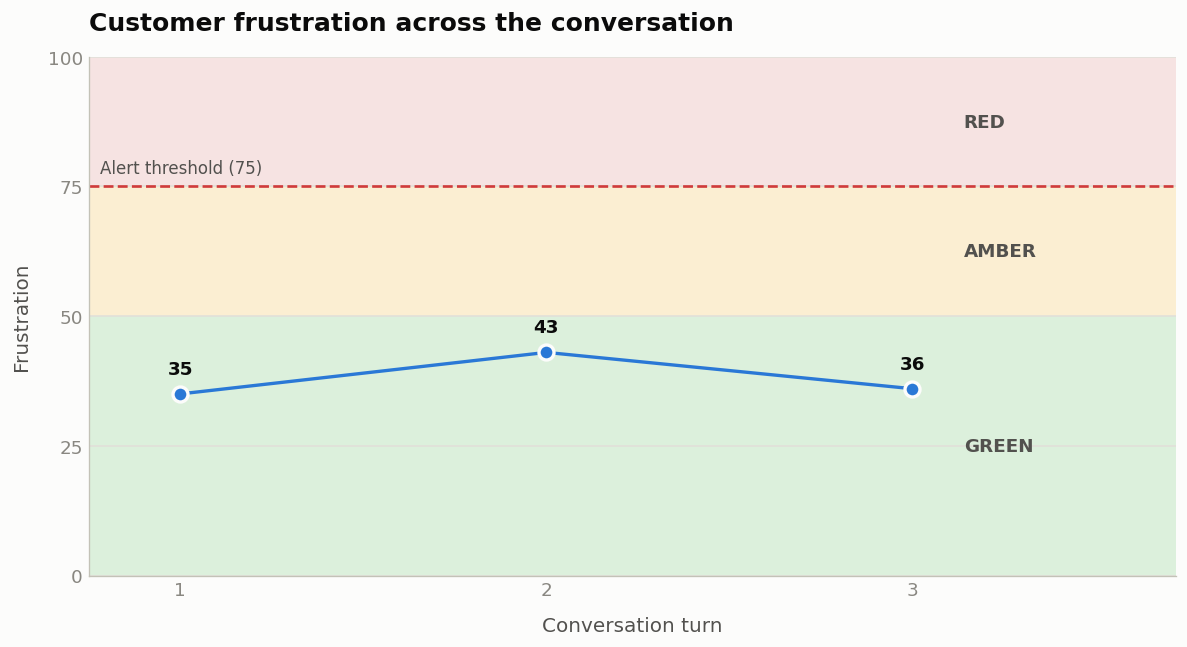

In [ ]:
# ===== Step 18: Plot the frustration trajectory (for the slide) =====

import matplotlib.pyplot as plt

# --- Data: reuse the real scores from the demo above ---
# If you have not run the "Built for Bharat" cell yet, we fall back to an
# example so this cell always produces a chart.
try:
    scores = list(predictor.scores)
except NameError:
    scores = []

if not scores:
    scores = [35, 58, 92]   # example trajectory
    print("(Using example data -- run the Built for Bharat demo for real scores.)")

turns = list(range(1, len(scores) + 1))


# --- Zone boundaries ---
# HEADS UP: these are the SLIDE bands. The EscalationPredictor class actually
# switches colour at MODERATE=45, HIGH=60 and VERY_HIGH=80. If you want the
# picture to match the code exactly, set these three from the class instead:
#     GREEN_TOP   = EscalationPredictor.MODERATE
#     AMBER_TOP   = EscalationPredictor.VERY_HIGH
#     ALERT_LEVEL = EscalationPredictor.VERY_HIGH
GREEN_TOP   = 50
AMBER_TOP   = 75
ALERT_LEVEL = 75

# --- Colours ---
# The line is BLUE on purpose. If the line were red it would compete with the
# red danger zone, and the reader could not tell data from background.
SURFACE    = "#fcfcfb"   # chart background
INK        = "#0b0b0b"   # main text
INK_SOFT   = "#52514e"   # axis titles, zone labels
INK_MUTED  = "#898781"   # tick numbers
GRID       = "#e1e0d9"   # hairline gridlines
AXIS       = "#c3c2b7"   # axis lines
LINE_BLUE  = "#2a78d6"   # the frustration line itself
ZONE_GREEN = "#0ca30c"
ZONE_AMBER = "#fab219"
ZONE_RED   = "#d03b3b"

fig, ax = plt.subplots(figsize=(10, 5.5), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

# --- Background zones ---
# Kept very pale (low alpha) so they stay in the background and the data line
# remains the thing your eye lands on first.
ax.axhspan(0,         GREEN_TOP, color=ZONE_GREEN, alpha=0.13, lw=0, zorder=0)
ax.axhspan(GREEN_TOP, AMBER_TOP, color=ZONE_AMBER, alpha=0.18, lw=0, zorder=0)
ax.axhspan(AMBER_TOP, 100,       color=ZONE_RED,   alpha=0.13, lw=0, zorder=0)

# Every zone gets a written label. Pale yellow on a white slide is genuinely
# hard to see, so the WORDS -- not the colour -- carry the meaning.
# They sit in a gutter to the right of the last turn, so they can never end up
# printed on top of the data line.
for y_middle, text in [((0 + GREEN_TOP) / 2,         "GREEN"),
                       ((GREEN_TOP + AMBER_TOP) / 2, "AMBER"),
                       ((AMBER_TOP + 100) / 2,       "RED")]:
    ax.text(len(turns) + 0.14, y_middle, text, ha="left", va="center",
            fontsize=11, color=INK_SOFT, fontweight="bold")

# --- The alert threshold ---
# Dashed, so it never gets mistaken for a gridline or for the data itself.
ax.axhline(ALERT_LEVEL, color=ZONE_RED, linestyle="--", linewidth=1.6, zorder=2)
ax.text(0.78, ALERT_LEVEL + 1.8, f"Alert threshold ({ALERT_LEVEL})",
        ha="left", va="bottom", fontsize=10, color=INK_SOFT)

# --- The frustration line ---
# White ring around each marker so points stay separate where the line is steep.
ax.plot(turns, scores,
        color=LINE_BLUE, linewidth=2, zorder=3,
        marker="o", markersize=9,
        markerfacecolor=LINE_BLUE, markeredgecolor=SURFACE, markeredgewidth=2)

# Print each score next to its point. With only a handful of turns this reads
# cleanly; the label flips below the point near the top so it never clips.
for x, y in zip(turns, scores):
    ax.annotate(f"{y}", (x, y),
                textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=11, color=INK, fontweight="bold")

# --- Axes and labels ---
ax.set_xlim(0.75, len(turns) + 0.72)
ax.set_ylim(0, 100)
ax.set_xticks(turns)                       # whole turns only: 1, 2, 3 ...
ax.set_yticks([0, 25, 50, 75, 100])

ax.set_xlabel("Conversation turn", fontsize=12, color=INK_SOFT, labelpad=10)
ax.set_ylabel("Frustration", fontsize=12, color=INK_SOFT, labelpad=10)
ax.set_title("Customer frustration across the conversation",
             fontsize=15, color=INK, fontweight="bold", loc="left", pad=16)

# Recessive chrome: hairline grid, no box around the plot.
ax.grid(axis="y", color=GRID, linewidth=1)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(AXIS)
ax.spines["bottom"].set_color(AXIS)
ax.tick_params(colors=INK_MUTED, length=0, labelsize=11)

plt.tight_layout()

# Save a high-resolution copy you can drop straight into the slide deck.
plt.savefig("frustration_trajectory.png", dpi=200, facecolor=SURFACE,
            bbox_inches="tight")
print("Saved as frustration_trajectory.png")

plt.show()

---

# Part 2: Upgrading the coach with a large language model (Gemini)

Everything above uses **small, specialised models**. Each one answers exactly one
question and nothing else: sentiment gives a mood, zero-shot gives an intent, and
our own Python rules turn those into advice.

That design has three limits the demo above shows honestly:

1. **The mood model gets Hinglish wrong.** In Step 17 it called *"ye kaisa service
   hai?? bahut ganda experience hai"* **POSITIVE**, so the escalation light stayed
   green for a customer who was clearly done.
2. **The advice is hard-coded.** `generate_coaching_feedback()` can only ever return
   one of the five sentences we typed into it.
3. **Nothing can write.** A classifier can label a complaint. It cannot draft the
   reply the agent actually has to send.

Part 2 keeps everything above and adds a second engine beside it: **one Gemini model
that does all of it in a single prompt** - mood, urgency, escalation risk, the key
issue, a score for the agent's reply, and a suggested reply written for them.

| | Part 1 (Hugging Face) | Part 2 (Gemini API) |
|---|---|---|
| Runs | Free, on the Colab machine | Free tier, over the internet |
| Hinglish | Weak, as Step 17 showed | Strong |
| Output | A label from a fixed list | Any JSON shape we ask for |
| Can write a reply | No | Yes |

> The library and your API key were already set up in Steps 1-2, so Part 2
> starts straight at the data models.

> **Rate-limit warning:** every cell below makes real API calls. The Gemini free
> tier allows only a few requests per minute, and Step 23 fires seven in a row. If
> you get a rate-limit error, wait a minute and run the cell again.

## Data models

Part 1 passed loose strings and lists between functions. Part 2 has more to remember
per turn, so we give the data a shape first.

A `@dataclass` is just a class where Python writes the boring `__init__` for us:
we list the fields, and we get a proper object with named attributes.

| Class | What it stores |
|---|---|
| `Message` | One line of the chat: who said it, and what they said. |
| `ConversationState` | The whole chat so far, plus the current risk reading. |
| `CoachingFeedback` | The three scores out of 10 and one coaching tip. |

In [ ]:
# ===== Step 19: DATA MODELS =====

@dataclass
class Message:
    """Represents one message in the conversation."""
    speaker: str
    text: str


@dataclass
class ConversationState:
    """Stores the complete conversation and current customer risk."""
    history: List[Message] = field(default_factory=list)
    sentiment: str = "unknown"
    urgency: str = "unknown"
    escalation_risk: str = "unknown"
    frustration: int = 0          # 0-100, judged across the whole conversation
    trend: str = "unknown"        # rising / falling / flat
    key_issue: str = ""

    def add_message(self, speaker: str, text: str):
        """Add a new message to the conversation history."""
        self.history.append(
            Message(
                speaker=speaker,
                text=text
            )
        )


@dataclass
class CoachingFeedback:
    """Stores feedback about the agent's response."""
    tone_score: int
    empathy_score: int
    clarity_score: int
    coaching_tip: str


print("Data models defined.")

Data models defined.


## The AI coach

`AICoach` is the only class that talks to Gemini. It has three jobs, and each job is
one prompt:

1. `analyze_customer_message()` - replaces Steps 4, 5 and 8 in one call: mood, urgency,
   escalation risk and the key issue.
2. `evaluate_agent_response()` - something Part 1 could never do. It reads what the
   **agent** wrote and scores it out of 10 for tone, empathy and clarity.
3. `suggest_reply()` - drafts the reply the agent can send.

Every prompt ends by demanding **JSON in an exact shape**. That is the trick that turns
a chatbot into a component: prose is for humans, JSON is something `ConversationState`
can store.

In [ ]:
# ===== Step 20: THE AI COACH =====

# ---- Response schemas ----
#
# These are handed to the API with each request. The model is then physically
# unable to return prose, a markdown code fence, a missing field, or a word
# outside an enum -- the API rejects it before we ever see it. The "enum" and
# "description" entries do real work: the model reads the descriptions, and
# the enums make the sentiment/urgency/trend values self-validating.

ANALYSIS_SCHEMA = {
    "type": "object",
    "properties": {
        "sentiment": {
            "type": "string", "enum": ["positive", "neutral", "negative"],
            "description": "How the customer sounds in their latest message.",
        },
        "urgency": {
            "type": "string", "enum": ["low", "medium", "high"],
            "description": "How quickly this needs an answer.",
        },
        "escalation_risk": {
            "type": "string", "enum": ["low", "medium", "high"],
            "description": "Chance this becomes a complaint or a cancellation.",
        },
        "frustration": {
            "type": "integer",
            "description": "How frustrated the customer is now, from 0 to 100.",
        },
        "trend": {
            "type": "string", "enum": ["rising", "falling", "flat"],
            "description": "Direction of frustration compared with earlier turns.",
        },
        "key_issue": {
            "type": "string",
            "description": "Short description of the customer's main problem.",
        },
    },
    "required": ["sentiment", "urgency", "escalation_risk",
                 "frustration", "trend", "key_issue"],
}

SCORECARD_SCHEMA = {
    "type": "object",
    "properties": {
        "tone_score": {"type": "integer", "description": "Tone, 1 to 10."},
        "empathy_score": {"type": "integer", "description": "Empathy, 1 to 10."},
        "clarity_score": {"type": "integer", "description": "Clarity, 1 to 10."},
        "coaching_tip": {
            "type": "string",
            "description": "One sentence naming the specific change to make.",
        },
    },
    "required": ["tone_score", "empathy_score", "clarity_score", "coaching_tip"],
}

REPLY_SCHEMA = {
    "type": "object",
    "properties": {
        "reply": {
            "type": "string",
            "description": "The reply text the agent should send, and nothing else.",
        },
    },
    "required": ["reply"],
}


# ==========================================================================
# Keeping personal details away from the model
# ==========================================================================
#
# Every customer message we send to Gemini leaves this machine and lands on
# somebody else's servers. A support chat is full of things that should not
# make that trip: phone numbers, email addresses, card numbers.
#
# So we swap them for placeholders on the way OUT, and put the real values
# back on the way IN. The model reasons about "[PHONE_1]" and never learns
# the number; the customer still reads their own details in the reply.
#
# Order ids get the same treatment, with one wrinkle handled in gather_facts():
# a tool call needs the REAL id to look anything up, so the placeholder is
# swapped back just before the function runs -- inside our own process.

REDACTION_PATTERNS = [
    # Order matters. Emails contain digits, so they must be taken out before
    # anything goes looking for numbers.
    ("EMAIL", re.compile(r"[\w.+-]+@[\w-]+\.[\w.-]+")),
    ("CARD",  re.compile(r"\b(?:\d[ -]?){12,18}\d\b")),
    ("ORDER", re.compile(r"\b(?:OD|RF|ORD|INV)[-_]?\d{3,8}\b", re.IGNORECASE)),
    ("PHONE", re.compile(
        r"(?:\+\d{1,3}[\s-]?)?\b\d{5}[\s-]?\d{5}\b"      # +91 98765 43210
        r"|\b\d{10}\b"                                     # 9876543210
    )),
]


def mask(value):
    """A hint of the original, for our own logs. Never the whole thing."""
    text = str(value)
    if "@" in text:
        name, _, domain = text.partition("@")
        return (name[:2] + "***@" + domain) if len(name) > 2 else "***@" + domain
    if len(text) <= 4:
        return "*" * len(text)
    return text[:2] + "*" * (len(text) - 4) + text[-2:]


class Redactor:
    """Swaps personal details for placeholders, and back again.

    One instance per conversation, so the same phone number keeps the same
    placeholder from turn to turn -- otherwise the model would think it was
    looking at two different people.
    """

    def __init__(self):
        self.to_real = {}      # "[PHONE_1]" -> "+91 98765 43210"
        self.to_token = {}     # "+91 98765 43210" -> "[PHONE_1]"
        self.found = []        # what we took out, for the audit log

    def redact(self, text):
        """Return text with personal details replaced by placeholders."""
        if not text:
            return text

        cleaned = str(text)

        for kind, pattern in REDACTION_PATTERNS:
            # kind is bound as a default argument, not captured from the loop.
            # It is safe either way here -- pattern.sub() runs swap before the
            # next iteration -- but binding it says so, and keeps the linter's
            # late-binding warning meaningful everywhere else.
            def swap(match, kind=kind):
                original = match.group(0)

                # Seen before in this conversation? Reuse its placeholder.
                if original in self.to_token:
                    return self.to_token[original]

                count = sum(1 for f in self.found if f["kind"] == kind) + 1
                token = f"[{kind}_{count}]"

                self.to_token[original] = token
                self.to_real[token] = original
                self.found.append({"kind": kind, "placeholder": token,
                                   "masked": mask(original)})
                return token

            cleaned = pattern.sub(swap, cleaned)

        return cleaned

    def restore(self, text):
        """Put the real values back.

        Models do not always echo a placeholder exactly as given -- they drop
        the brackets and write ORDER_1, or lower-case it. Matching only the
        exact form left "Refund for order ORDER_1" in front of a customer, so
        the bare and lower-cased forms are handled too.
        """
        if not text:
            return text

        restored = str(text)

        for token, original in self.to_real.items():
            bare = token.strip("[]")
            for variant in (token, bare, token.lower(), bare.lower()):
                restored = restored.replace(variant, original)

        return restored

    def log(self):
        """What was taken out, for the case record. Masked, not the originals."""
        return list(self.found)


# ==========================================================================
# The back office -- what the coach can actually look up and do
# ==========================================================================
#
# A support tool that only talks is a chatbot. One that can read the order
# system and act on it is an agent. These four functions stand in for that
# system, backed by orders.json.
#
# The model never runs them itself. It asks for a function BY NAME, our code
# decides whether to run it, runs it, and only then does the model see the
# result. That boundary is the whole point: the model can *request* a refund;
# the code decides whether one actually happens.


def orders_path():
    """Find orders.json, reusing the same folder search as the key file."""
    for folder in key_file_folders():
        candidate = os.path.join(folder, "orders.json")
        if os.path.isfile(candidate):
            return candidate
    return ""


def load_orders():
    path = orders_path()
    if not path:
        return {}
    try:
        with open(path) as handle:
            return json.load(handle)
    except (json.JSONDecodeError, OSError):
        return {}


def save_orders(data):
    """Write the mock back office back to disk, atomically."""
    path = orders_path()
    if not path:
        return False
    tmp = path + ".tmp"
    with open(tmp, "w") as handle:
        json.dump(data, handle, indent=1)
    os.replace(tmp, path)
    return True


# ---- the four tools ----

def check_order_status(order_id=None):
    """Look up one order, or list the recent ones if no id was given."""
    data = load_orders()
    orders = data.get("orders", [])

    if not orders:
        return {"error": "The order system is unavailable."}

    if order_id:
        for order in orders:
            if order["order_id"].lower() == str(order_id).lower():
                return order
        return {"error": f"No order {order_id} exists on this account."}

    # The customer rarely quotes an order number, so default to showing
    # what they recently bought rather than demanding one.
    return {"recent_orders": orders[:3]}


def check_refund_status(order_id=None, refund_id=None):
    """Look up a refund by either the refund id or the order it belongs to."""
    data = load_orders()
    refunds = data.get("refunds", [])

    for refund in refunds:
        if refund_id and refund["refund_id"].lower() == str(refund_id).lower():
            return refund
        if order_id and refund["order_id"].lower() == str(order_id).lower():
            return refund

    if order_id or refund_id:
        return {"error": "No refund has been raised for that order yet."}

    return {"refunds": refunds} if refunds else {"error": "No refunds on file."}


def issue_refund(order_id, reason="Requested by customer"):
    """Raise a refund against an order. THIS CHANGES DATA."""
    data = load_orders()
    orders = data.get("orders", [])

    order = next((o for o in orders
                  if o["order_id"].lower() == str(order_id).lower()), None)
    if order is None:
        return {"error": f"No order {order_id} exists on this account."}

    existing = next((r for r in data.get("refunds", [])
                     if r["order_id"].lower() == str(order_id).lower()), None)
    if existing:
        return {"error": "A refund already exists for this order.",
                "refund": existing}

    today = datetime.now()
    refund = {
        "refund_id": f"RF-{9000 + len(data.get('refunds', [])) + 13}",
        "order_id": order["order_id"],
        "amount": order["amount"],
        "currency": order.get("currency", "INR"),
        "status": "processing",
        "initiated_on": today.strftime("%Y-%m-%d"),
        "expected_by": (today + timedelta(days=5)).strftime("%Y-%m-%d"),
        "method": "original payment method",
        "reason": reason,
    }
    data.setdefault("refunds", []).append(refund)
    save_orders(data)
    return refund


def send_password_reset(email=None):
    """Send a password reset link. THIS CHANGES DATA."""
    data = load_orders()
    account = data.get("account", {})

    if not account:
        return {"error": "The account system is unavailable."}

    if email and email.lower() != account.get("email", "").lower():
        return {"error": "That email is not on this account."}

    stamp = datetime.now().isoformat(timespec="seconds")
    account["password_reset_sent_at"] = stamp
    data["account"] = account
    save_orders(data)
    return {"sent_to": account.get("email"), "sent_at": stamp,
            "expires_in_minutes": 30}


# ---- what the model is allowed to ask for ----
#
# "writes" marks the two that change data. Those are NOT run automatically --
# see gather_facts() below.

BACK_OFFICE = {
    "check_order_status": {
        "run": check_order_status, "writes": False,
        "declaration": types.FunctionDeclaration(
            name="check_order_status",
            description="Look up the status of an order. Omit order_id to "
                        "list the customer's recent orders.",
            parameters_json_schema={
                "type": "object",
                "properties": {
                    "order_id": {"type": "string",
                                 "description": "e.g. OD-4471. Optional."},
                },
            },
        ),
    },
    "check_refund_status": {
        "run": check_refund_status, "writes": False,
        "declaration": types.FunctionDeclaration(
            name="check_refund_status",
            description="Look up a refund by refund id or by the order it "
                        "belongs to.",
            parameters_json_schema={
                "type": "object",
                "properties": {
                    "order_id": {"type": "string", "description": "e.g. OD-4471"},
                    "refund_id": {"type": "string", "description": "e.g. RF-9012"},
                },
            },
        ),
    },
    "issue_refund": {
        "run": issue_refund, "writes": True,
        "declaration": types.FunctionDeclaration(
            name="issue_refund",
            description="Raise a refund against an order. Changes data, so it "
                        "needs a human to approve it.",
            parameters_json_schema={
                "type": "object",
                "properties": {
                    "order_id": {"type": "string", "description": "e.g. OD-4471"},
                    "reason": {"type": "string",
                               "description": "Why the refund is being raised"},
                },
                "required": ["order_id"],
            },
        ),
    },
    "send_password_reset": {
        "run": send_password_reset, "writes": True,
        "declaration": types.FunctionDeclaration(
            name="send_password_reset",
            description="Email a password reset link. Changes data, so it "
                        "needs a human to approve it.",
            parameters_json_schema={
                "type": "object",
                "properties": {
                    "email": {"type": "string",
                              "description": "The account email. Optional."},
                },
            },
        ),
    },
}

BACK_OFFICE_TOOL = types.Tool(
    function_declarations=[t["declaration"] for t in BACK_OFFICE.values()]
)


class AICoach:
    """Every call we make to the Gemini API lives in this class."""

    def __init__(self):
        """Create the Gemini client."""

        # The key is normally set in Step 2, but this class is used 19 cells
        # later. If Step 2 was skipped, or the kernel restarted, or the prompt
        # was dismissed, this asks again HERE -- at the moment the key is
        # actually needed -- instead of failing and making you scroll back up.
        api_key = get_gemini_api_key()

        if not api_key:
            raise ValueError(
                "No Gemini API key available, so Part 2 cannot run. "
                "Get a free key at https://aistudio.google.com/apikey and "
                "run Step 2 again."
            )

        self.client = genai.Client(api_key=api_key)
        self.last_redactions = []      # what the most recent call took out
        self.last_article = None       # the help article behind the last reply

        # You can change this through an environment variable, for example
        # os.environ["GEMINI_MODEL"] = "gemini-3.7-flash" for the newest model.
        self.model = os.getenv(
            "GEMINI_MODEL",
            "gemini-3.5-flash"
        )

    # ---------------- Helper functions ----------------

    def _clean(self, *texts):
        """Strip personal details out of everything about to be sent.

        A fresh Redactor per call, so one customer's details can never leak
        into another customer's placeholders, and the map cannot grow without
        bound over a long-running server.
        """
        redactor = Redactor()
        return redactor, [redactor.redact(text) for text in texts]


    # If our first-choice model is busy, try these next, in order. Free-tier
    # models get overloaded at peak times, and a demo should survive that.
    FALLBACK_MODELS = ["gemini-3.5-flash", "gemini-3.5-flash-lite"]

    # Errors worth waiting out: 503 = model busy, 429 = rate limited.
    RETRYABLE = ["503", "429", "UNAVAILABLE", "RESOURCE_EXHAUSTED"]
    # A malformed request is our fault, not the model's -- every other model
    # rejects it in exactly the same way, so falling back only doubles the
    # latency and the quota spent before we give up.
    FATAL = ["400", "INVALID_ARGUMENT", "401", "403", "PERMISSION_DENIED"]

    def _call_model(self, contents, config=None, max_attempts: int = 3):
        """One request to Gemini, with retries and model fallback.

        Every call goes through here -- plain text, structured JSON and tool
        calling alike. Tool calling in particular has a tighter free-tier
        limit than ordinary generation, so it needs this even more than the
        others do.
        """
        models_to_try = [self.model]
        for name in self.FALLBACK_MODELS:
            if name not in models_to_try:
                models_to_try.append(name)

        last_problem = "no attempt was made"

        for model_name in models_to_try:
            for attempt in range(max_attempts):
                try:
                    response = self.client.models.generate_content(
                        model=model_name,
                        contents=contents,
                        config=config,
                    )
                    self.last_model_used = model_name
                    return response

                except Exception as error:
                    last_problem = f"{type(error).__name__}: {error}"

                    if any(code in str(error) for code in self.RETRYABLE):
                        time.sleep(2 ** attempt)      # 1s, then 2s, then 4s
                        continue

                    if any(code in str(error) for code in self.FATAL):
                        raise ValueError(
                            f"Gemini rejected the request -> {last_problem}"
                        ) from error

                    break        # will not fix itself; try the next model

        raise ValueError(
            "Gemini could not be reached after trying "
            f"{', '.join(models_to_try)}. Last problem -> {last_problem}"
        )

    def _ask_model(
        self,
        prompt: str,
        schema: Optional[dict] = None,
        max_attempts: int = 3
    ) -> str:
        """Send one prompt to Gemini and return the reply as plain text.

        Pass a schema and the API guarantees the reply is JSON in that exact
        shape.
        """

        # Only build a config when we actually want structured output.
        config = None
        if schema is not None:
            config = types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=schema,
            )

        response = self._call_model(prompt, config, max_attempts)

        # response.text is None when the model returned no text at all -- for
        # example when a safety filter blocked the answer.
        text = (response.text or "").strip()

        if not text:
            raise ValueError(
                "The model returned no text. It may have been blocked by a "
                "safety filter, or you may have hit the free-tier rate limit."
            )

        return text

    def _ask_for_json(self, prompt: str, schema: dict) -> dict:
        """Ask for JSON whose shape the API itself guarantees."""
        return self._parse_json(self._ask_model(prompt, schema=schema))

    def _parse_json(self, text: str) -> dict:
        """Turn the model's reply into a Python dictionary.

        With a response schema this is now a safety net rather than the thing
        holding everything together: the API has already validated the shape.
        It still earns its place, because a fallback model that ignores the
        schema would land right back here.
        """

        text = text.strip()

        # Sometimes the reply is wrapped in a ```json ... ``` code fence.
        if text.startswith("```"):
            text = text.strip("`").strip()

            if text.lower().startswith("json"):
                text = text[4:].strip()

        try:
            return json.loads(text)

        except json.JSONDecodeError as e:

            print("\nCould not parse the model response as JSON.")
            print("Raw response:")
            print(text)

            raise ValueError(
                f"Invalid JSON returned by the model: {e}"
            )

    # ---------------- 1. Analyze customer message ----------------

    def analyze_customer_message(
        self,
        customer_message: str,
        conversation_history: Optional[List[Message]] = None
    ) -> dict:
        """Judge the latest customer message IN CONTEXT.

        Escalation is a property of a conversation, not of a sentence. Asked
        about one message on its own, the model cannot see that a customer
        opened politely and has been getting angrier for four turns -- which
        is the whole thing we care about. So we hand it the transcript and let
        it judge the trajectory directly, including a 0-100 frustration score.
        """

        # The whole conversation, ending with the message we are judging.
        turns = list(conversation_history or [])

        if not turns or turns[-1].text != customer_message:
            turns.append(Message(speaker="customer", text=customer_message))

        transcript = "\n".join(f"{turn.speaker}: {turn.text}" for turn in turns)
        redactor, (transcript,) = self._clean(transcript)

        prompt = f"""
You are an AI customer-support risk analyzer.

Read the WHOLE conversation below, then judge the customer as of their last
message. Earlier turns are context: they change what the last message means.

Conversation:
{transcript}

How to judge:
- A customer who opened politely and has grown angrier over several turns is
  at HIGHER risk than the same words would suggest on their own.
- A customer whose tone improved after a good agent reply is at LOWER risk
  than their angriest moment suggests.
- Repeating the same unresolved problem is itself a strong escalation signal,
  however politely it is phrased.
- If this is the first customer message, there is no trajectory yet, so the
  trend is "flat".

The shape of your answer is fixed by the response schema, so just fill it in.
"""

        # ANALYSIS_SCHEMA guarantees every field is present and that sentiment,
        # urgency and trend hold one of their allowed words.
        reading = self._ask_for_json(prompt, ANALYSIS_SCHEMA)

        # key_issue is written by the model and may quote a placeholder back
        # at us, so put the real values in before anyone reads it.
        reading["key_issue"] = redactor.restore(reading.get("key_issue", ""))
        self.last_redactions = redactor.log()

        # The score has to be a usable number whatever the model returns.
        try:
            reading["frustration"] = max(0, min(100, int(reading.get("frustration"))))
        except (TypeError, ValueError):
            # Fall back to the old word-to-number mapping rather than crash.
            reading["frustration"] = {
                "low": 25, "medium": 55, "high": 90
            }.get(reading.get("escalation_risk"), 35)

        if reading.get("trend") not in ("rising", "falling", "flat"):
            reading["trend"] = "flat"

        return reading

    # ---------------- 2. Evaluate agent response ----------------

    def evaluate_agent_response(
        self,
        customer_message: str,
        agent_message: str
    ) -> CoachingFeedback:

        redactor, (customer_message, agent_message) = self._clean(
            customer_message, agent_message)

        prompt = f"""
You are an AI customer-support coach. Score one agent reply.

Customer message:
{customer_message}

Agent reply:
{agent_message}

Score each dimension from 1 to 10 using these bands.

TONE -- is the wording professional, warm and appropriately serious?
  1-3    Curt, robotic or dismissive. Blames the customer, or reads like a
         form letter. No greeting and no courtesy.
  4-6    Polite but flat. Correct, with no warmth. Could have been sent to
         anybody about anything.
  7-10   Warm and professional. Sounds like a person who actually read the
         message and takes it seriously.

EMPATHY -- does the reply show the agent understood how the customer feels?
  1-3    Feelings ignored completely. Straight into process, or a bare
         demand for information.
  4-6    A token line ("sorry for the inconvenience") with nothing specific
         to this customer's situation.
  7-10   Names this customer's actual problem and what it has cost them,
         before moving on to the fix.

CLARITY -- will the customer know exactly what happens next?
  1-3    Vague or confusing. No next step, or jargon they cannot act on.
  4-6    Understandable, but the next step or the timeline is missing.
  7-10   One clear next step, who does it, and by when.

Be strict, and use the whole scale. Apply the bands literally:
- A reply with NO acknowledgement at all -- only a demand for information --
  must not score above 3 for empathy.
- A reply with a generic apology and nothing specific to this customer belongs
  in the 4-6 empathy band. Do not push it below 4 just for being generic.

Then give ONE concrete coaching tip: name the specific change to make, and why.

The shape of your answer is fixed by the response schema, so just fill it in.
"""

        result = self._ask_for_json(prompt, SCORECARD_SCHEMA)
        result["coaching_tip"] = redactor.restore(result.get("coaching_tip", ""))
        self.last_redactions = redactor.log()

        return CoachingFeedback(
            tone_score=int(result["tone_score"]),
            empathy_score=int(result["empathy_score"]),
            clarity_score=int(result["clarity_score"]),
            coaching_tip=result["coaching_tip"]
        )

    # ---------------- 2b. Look things up in the back office ----------------

    def gather_facts(
        self,
        customer_message: str,
        conversation_history: Optional[List[Message]] = None,
        allow_writes: bool = False,
        max_rounds: int = 3
    ) -> list:
        """Let the model query the order system before we draft a reply.

        This is a real function-calling loop: the model replies with the NAME
        of a function it wants, we run it here, hand back the result, and let
        it decide whether it needs anything else.

        allow_writes is off by default on purpose. A model that can silently
        issue refunds is a liability, so `issue_refund` and
        `send_password_reset` are recorded as REQUESTED and left unrun until
        a person approves them.
        """
        turns = list(conversation_history or [])
        if not turns or turns[-1].text != customer_message:
            turns.append(Message(speaker="customer", text=customer_message))
        transcript = "\n".join(f"{t.speaker}: {t.text}" for t in turns)
        redactor, (transcript,) = self._clean(transcript)

        prompt = f"""
You decide what to look up in the order system before a support agent replies.

Conversation:
{transcript}

Call whichever functions would let us answer this customer with real facts
rather than generalities. Rules:
- Only call a function that is clearly relevant to what they are asking.
- Never invent an order id. If the customer has not given one, call
  check_order_status with no arguments to see their recent orders first.
- If nothing needs looking up, reply with the single word NONE.
"""

        history = [types.Content(role="user", parts=[types.Part(text=prompt)])]
        performed = []

        for _ in range(max_rounds):
            try:
                response = self._call_model(
                    history,
                    types.GenerateContentConfig(
                        tools=[BACK_OFFICE_TOOL],
                        # We run the functions ourselves, so the SDK must not.
                        automatic_function_calling=
                            types.AutomaticFunctionCallingConfig(disable=True),
                    ),
                )
            except Exception as error:
                # A lookup failing must never stop us replying to the customer.
                performed.append({"name": "(lookup unavailable)", "args": {},
                                  "result": {"error": str(error)[:120]},
                                  "writes": False, "ran": False})
                break

            calls = response.function_calls or []
            if not calls:
                break                     # the model is done asking

            replies = []
            for call in calls:
                tool = BACK_OFFICE.get(call.name)

                # The model asked using placeholders, because that is all it
                # was given. Put the real ids back before the function runs --
                # the lookup happens inside our own process, where the real
                # values were never a secret.
                args = {key: redactor.restore(value) if isinstance(value, str)
                             else value
                        for key, value in (call.args or {}).items()}

                if tool is None:
                    result = {"error": f"No such function: {call.name}"}
                    ran = False
                elif tool["writes"] and not allow_writes:
                    # Requested, deliberately not run.
                    result = {"status": "awaiting approval",
                              "detail": "A person must approve this action "
                                        "before it is carried out."}
                    ran = False
                else:
                    try:
                        result = tool["run"](**args)
                        ran = True
                    except Exception as error:
                        result = {"error": f"{type(error).__name__}: {error}"}
                        ran = False

                performed.append({"name": call.name, "args": args,
                                  "result": result,
                                  "writes": bool(tool and tool["writes"]),
                                  "ran": ran})
                # The RESULT is full of real order ids, emails and amounts,
                # and it is about to be sent straight back to the model. Clean
                # it on the way out; the untouched copy stays in `performed`
                # for the agent to see.
                replies.append(types.Part.from_function_response(
                    name=call.name,
                    response={"result": json.loads(
                        redactor.redact(json.dumps(result)))}))

            history.append(response.candidates[0].content)
            # The API rejects role="tool" outright:
            #   Role 'tool' is not supported. Please use a valid role:
            #   SYSTEM, ... MODEL, USER.
            # Function results are handed back as a USER turn. Getting this
            # wrong meant round 1 worked and every round after it 400'd, so
            # the model could never chain two lookups together.
            history.append(types.Content(role="user", parts=replies))

        self.last_redactions = redactor.log()
        return performed

    # ---------------- 3. Suggest reply ----------------

    def suggest_reply(
        self,
        customer_message: str,
        conversation_history: Optional[List[Message]] = None,
        analysis: Optional[dict] = None,
        facts: Optional[list] = None
    ) -> str:

        # ---- 1. The conversation, written out exactly ONCE ----
        #
        # The history we are handed normally ends with the agent's own attempt
        # -- the very message we are being asked to improve on. Leaving it in
        # asks the model to reply to a conversation that has already been
        # replied to, so we trim any trailing agent turns off.
        #
        # This also fixes a real bug: the old version printed the customer
        # message once on its own AND again inside the history, so the model
        # saw it twice.
        turns = list(conversation_history or [])

        while turns and turns[-1].speaker == "agent":
            turns.pop()

        # Make sure the message we are replying to really is the last line.
        if not turns or turns[-1].text != customer_message:
            turns.append(Message(speaker="customer", text=customer_message))

        transcript = "\n".join(f"{turn.speaker}: {turn.text}" for turn in turns)

        # ---- 2. What we already worked out about this customer ----
        # analyze_customer_message() computed this seconds ago. Throwing it
        # away and making the model guess again is pure waste.
        if analysis:
            reading = (
                f"- sentiment: {analysis.get('sentiment', 'unknown')}\n"
                f"- urgency: {analysis.get('urgency', 'unknown')}\n"
                f"- main issue: {analysis.get('key_issue', 'not identified')}"
            )
        else:
            reading = "- no analysis was available for this turn"

        # ---- 3. The one piece of ground truth we can offer ----
        # Without this the model has NO facts, so "do not over-promise" is an
        # instruction it cannot actually follow -- all it can write is vague
        # filler. find_kb_article() comes from Step 14; if you jumped straight
        # to Part 2 without running it we carry on unarmed rather than crash.
        article = None
        try:
            article = find_kb_article(customer_message)
            if article is None and analysis and analysis.get("key_issue"):
                article = find_kb_article(analysis["key_issue"])
        except NameError:
            pass

        # Remember whether we had anything to ground this reply in, so the
        # rating it gets can be read against that. A suggestion written from
        # a real help article and one written from nothing are not the same
        # product, and lumping their scores together hides that.
        self.last_article = article

        if article:
            policy = (
                f'Our help article on "{article["topic"]}" says:\n'
                f'"""\n{article["article"]}\n"""\n\n'
                "Every timeline, step and condition in your reply must match "
                "this article exactly, but put them in your own words. Do not "
                "add any figure, deadline or promise that is not written above."
            )
        else:
            policy = (
                "NO help article matched this question, so you have no policy "
                "to quote.\n\n"
                "Do NOT invent a refund window, a delivery date, an amount, or "
                "any other commitment. Acknowledge the problem, say you are "
                "checking with the relevant team, and promise to come back."
            )

        # ---- 4. Anything we actually looked up in the order system ----
        # These are real records, not the model's memory, so they outrank
        # everything else in the prompt.
        if facts:
            lines = []
            for fact in facts:
                if fact.get("ran"):
                    lines.append(f"- {fact['name']}({json.dumps(fact['args'])})"
                                 f" returned: {json.dumps(fact['result'])}")
                else:
                    lines.append(f"- {fact['name']} was NOT carried out: "
                                 f"{json.dumps(fact['result'])}")
            lookups = (
                "What our order system says (these are real records — use them "
                "in preference to anything else, and quote the exact ids, dates "
                "and amounts):\n" + "\n".join(lines) +
                "\n\nIf an action was not carried out, do not tell the customer "
                "it was done. Say it is being arranged."
            )
        else:
            lookups = "We did not look anything up in the order system for this turn."

        # Everything above is about to leave the machine, so it all gets
        # cleaned -- the transcript, our own analysis, the order records and
        # the help article alike.
        redactor, (transcript, reading, lookups, policy) = self._clean(
            transcript, reading, lookups, policy)

        prompt = f"""
You are an expert customer-support agent. Write the agent's next reply.

Conversation so far (you are replying to the last line):
{transcript}

What our analysis says about this customer right now:
{reading}

{lookups}

{policy}

Requirements:
- Acknowledge the concern, and match your tone to the sentiment and urgency above.
- Show empathy without being sugary.
- State the next concrete step.
- Never promise anything the help article does not support.
- Write the WHOLE reply in clear, simple English, even when the customer wrote
  in Hinglish. Do not mix languages within a sentence.
- Keep it under 90 words.
"""

        # This one returns prose, so there is no JSON shape to guarantee. The
        # schema still earns its keep: a single "reply" field makes it
        # impossible to prepend "Here is a reply:" or wrap the answer in
        # commentary, which used to be an instruction the model could ignore.
        reply = self._ask_for_json(prompt, REPLY_SCHEMA)["reply"].strip()
        self.last_redactions = redactor.log()

        # The customer is entitled to see their own details, so the real
        # values go back in before the reply is shown to anyone.
        return redactor.restore(reply)


print("AICoach defined.")

AICoach defined.


In [ ]:
# ===== Step 21: Quick test -- the message Part 1 got wrong =====

# This is the Hinglish line from the Step 17 demo. The small sentiment model
# called it POSITIVE (64% confident) and left the escalation light on green.
# Here is what a large language model makes of the same sentence.

coach = AICoach()

analysis = coach.analyze_customer_message(
    "ye kaisa service hai?? bahut ganda experience hai"
)

# The result is a normal Python dictionary, so we can print it key by key.
for name, value in analysis.items():
    print(f"{name:>16} : {value}")

## Real-time coaching session

`RealTimeCoachingSession` is the part a support agent would actually sit in front of.
It holds the memory (`ConversationState`) and calls the coach at the right moments:

- **`on_customer_message()`** - the customer typed something. Store it, analyse it,
  and show the live risk panel.
- **`on_agent_message()`** - the agent typed something. Store it, score it against the
  last customer message, and show a suggested reply.
- **`print_summary()`** - the wrap-up at the end of the chat.

This is the same event-driven shape a real chat tool uses: the UI calls a method when a
message arrives, and the coach panel updates itself.

In [ ]:
# ===== Step 22: REAL-TIME COACHING SESSION =====

class RealTimeCoachingSession:

    def __init__(self):

        self.state = ConversationState()

        self.coach = AICoach()

        # Keep the previous customer message so that
        # the next agent response can be evaluated.
        self.last_customer_message = ""

    # ---------------- Customer message ----------------

    def on_customer_message(
        self,
        message: str
    ):

        print("\n" + "=" * 60)
        print("CUSTOMER")
        print("=" * 60)

        print(message)

        # Add message to conversation
        self.state.add_message(
            "customer",
            message
        )

        self.last_customer_message = message

        # Analyze the customer IN CONTEXT -- the whole conversation so far,
        # so the model can see a trajectory instead of one isolated sentence.
        analysis = self.coach.analyze_customer_message(
            message,
            self.state.history
        )

        # Update conversation state
        self.state.sentiment = analysis["sentiment"]
        self.state.urgency = analysis["urgency"]
        self.state.escalation_risk = analysis["escalation_risk"]
        self.state.frustration = analysis["frustration"]
        self.state.trend = analysis["trend"]
        self.state.key_issue = analysis["key_issue"]

        # Show the live risk panel to the agent
        print("\n-- LIVE ANALYSIS --")
        print(f"Sentiment       : {self.state.sentiment}")
        print(f"Urgency         : {self.state.urgency}")
        print(f"Escalation risk : {self.state.escalation_risk}")
        print(f"Frustration     : {self.state.frustration}/100 ({self.state.trend})")
        print(f"Key issue       : {self.state.key_issue}")

        return analysis

    # ---------------- Agent message ----------------

    def on_agent_message(
        self,
        message: str
    ):

        print("\n" + "=" * 60)
        print("AGENT")
        print("=" * 60)

        print(message)

        # Add message to conversation
        self.state.add_message(
            "agent",
            message
        )

        # There is nothing to score against if the agent spoke first.
        if not self.last_customer_message:
            print("\n(No customer message yet, so there is nothing to score.)")
            return None

        # Score the agent's reply
        feedback = self.coach.evaluate_agent_response(
            self.last_customer_message,
            message
        )

        print("\n-- COACHING --")
        print(f"Tone    : {feedback.tone_score}/10")
        print(f"Empathy : {feedback.empathy_score}/10")
        print(f"Clarity : {feedback.clarity_score}/10")
        print(f"Tip     : {feedback.coaching_tip}")

        # Show what a strong reply could have looked like. We hand over the
        # analysis we already computed, so the draft is written for THIS
        # customer's mood rather than a generic upset one.
        suggestion = self.coach.suggest_reply(
            self.last_customer_message,
            self.state.history,
            analysis={
                "sentiment": self.state.sentiment,
                "urgency": self.state.urgency,
                "key_issue": self.state.key_issue,
            }
        )

        print("\n-- SUGGESTED REPLY --")
        print(suggestion)

        return feedback

    # ---------------- End of chat ----------------

    def print_summary(self):

        print("\n" + "=" * 60)
        print("SESSION SUMMARY")
        print("=" * 60)

        print(f"Messages exchanged : {len(self.state.history)}")
        print(f"Final sentiment    : {self.state.sentiment}")
        print(f"Final urgency      : {self.state.urgency}")
        print(f"Escalation risk    : {self.state.escalation_risk}")
        print(f"Frustration        : {self.state.frustration}/100 ({self.state.trend})")
        print(f"Key issue          : {self.state.key_issue}")


print("RealTimeCoachingSession defined.")

RealTimeCoachingSession defined.


## Live Demo — the same Bharat conversation, coached by Gemini

This is the **same failed-recharge conversation** as the Step 17 demo, so the two
engines can be compared side by side on identical input.

Watch the escalation risk. In Part 1 it read `green -> green -> green` and the agent
would have been told nothing was wrong.

Each `on_customer_message()` is 1 API call and each `on_agent_message()` is 2, so this
cell makes **7 calls** in total.

In [ ]:
# ===== Step 23: LIVE DEMO -- Gemini coaching the whole conversation =====

session = RealTimeCoachingSession()

# Turn 1 -- polite and factual
session.on_customer_message(
    "hello, mera recharge nahi hua but paise cut gaye"
)

session.on_agent_message(
    "Let me check that for you, please hold."
)

# Turn 2 -- patience thinning
session.on_customer_message(
    "bhai 2 din ho gaye, abhi tak refund nahi aaya"
)

session.on_agent_message(
    "I am really sorry for the delay."
)

# Turn 3 -- done being polite
session.on_customer_message(
    "ye kaisa service hai?? bahut ganda experience hai"
)

# Wrap-up
session.print_summary()

## Bringing the two halves together

Earlier this section had to translate. `analyze_customer_message()` judged one
message at a time, so its `low` / `medium` / `high` had to be mapped onto the
0-100 scale `EscalationPredictor` thinks in — a lookup table with exactly three
possible values. A "trajectory" built from three possible numbers is barely a
trajectory at all.

That is fixed. The analyser now reads the **whole conversation** and returns a
real frustration score and its own `trend`, so the lookup table is gone.

What is left is more interesting than a translation layer:

- **Gemini** reads the language — it knows that *"ye kaisa service hai??"* is not
  a question, and it can see that turn 3 is angrier than turn 1.
- **`EscalationPredictor` (Step 12)** applies a rule you can read, audit and
  defend in a viva. It has no opinions; it just does arithmetic on the numbers
  it is given.

Feeding the model's scores into the rule gives you two independent readings of
the same conversation. When they agree, you can trust the call. **When they
disagree, that is the conversation worth looking at by hand.**


In [ ]:
# ===== Step 24: Gemini's own trajectory, cross-checked against Step 12 =====

# This cell needs EscalationPredictor from Step 12, so run Part 1 first.
if "EscalationPredictor" not in globals():
    raise NameError(
        "EscalationPredictor is missing -- run the Step 12 cell in Part 1 first."
    )

# WHAT CHANGED HERE
#
# This cell used to translate Gemini's low/medium/high into a number with a
# RISK_TO_SCORE lookup, because analyze_customer_message() only ever saw one
# message at a time. That mapping had only three possible values, so the
# "trajectory" could only ever be flat or a 35-point jump.
#
# analyze_customer_message() now reads the whole conversation and returns a
# real 0-100 frustration score plus its own trend. The translation layer is
# gone. What is left is worth more: two independent opinions on the same
# conversation -- Gemini's, and the deterministic tracker from Part 1 fed on
# Gemini's numbers. Where they disagree is where you look.

conversation_lines = [
    "hello, mera recharge nahi hua but paise cut gaye",
    "bhai 2 din ho gaye, abhi tak refund nahi aaya",
    "ye kaisa service hai?? bahut ganda experience hai",
]

# A fresh predictor, so this run is independent of the Part 1 demo above.
gemini_predictor = EscalationPredictor()

# One coach for all three turns (reuse it -- creating it per turn is wasteful).
bridge_coach = AICoach()

# We build the transcript up as we go, exactly like a live chat would.
history = []

for turn_number, line in enumerate(conversation_lines, start=1):

    history.append(Message(speaker="customer", text=line))

    # 1. Gemini reads the conversation SO FAR, not just this line.
    reading = bridge_coach.analyze_customer_message(line, history)

    # 2. Its frustration score goes straight in -- no translation needed.
    gemini_predictor.add_turn(reading["frustration"])
    status = gemini_predictor.get_risk()

    agree = "agree" if status["trend"] == reading["trend"] else "DISAGREE"

    print("=" * 70)
    print(f"TURN {turn_number} : {line}")
    print(f"  sentiment      : {reading['sentiment']} / urgency {reading['urgency']}")
    print(f"  frustration    : {reading['frustration']}/100   "
          f"history: {gemini_predictor.scores}")
    print(f"  trend          : Gemini says '{reading['trend']}', "
          f"Step 12 tracker says '{status['trend']}'  -> {agree}")
    print(f"  ESCALATION     : [{status['level'].upper()}] {status['alert']}")

print("=" * 70)
print("Part 1 alone reported : green -> green -> green")
print("Gemini's own scores   :",
      " -> ".join(str(s) for s in gemini_predictor.scores))
print()
print("Two independent readings of one conversation. The model brings language")
print("understanding; the Part 1 tracker brings a rule you can audit. Neither")
print("needs a lookup table to translate between them any more.")


## Notes for the viva

**Why keep Part 1 at all, if Gemini does everything?**
Speed, cost and auditability. The Hugging Face models run on the machine and answer
in milliseconds with no quota; every Gemini call crosses the internet, takes a second
or two, and counts against a rate limit. `EscalationPredictor` is also a rule you can
read line by line and defend — the model is not. A real product would run the cheap
checks on *every* message and call the expensive one only when they disagree.

**What is the actual finding?**
That a pipeline is only as strong as its weakest signal. In Step 11 the multilingual
sentiment model reads *"bahut ganda service hai"* as **POSITIVE (49.8%)**, and in
Step 17 the escalation light stays green through a conversation that plainly decays.
The tracker is not broken — Step 13 shows the same class climbing `35 → 35 → 43 → 94`
and firing red on English input. The **input** was wrong. Part 2 replaces that input:
on the identical sentence Gemini returns `negative`, frustration **85/100**, risk
**high**.

**Why ask for JSON, and why a response schema?**
An LLM answers in prose, which Python cannot use. Pinning the fields turns free text
into a dictionary that drops straight into `ConversationState`. The **response schema**
goes further: the API itself rejects a reply that is missing a field or uses a word
outside an enum, so `_parse_json()` is now a safety net rather than the thing holding
it together.

**Why does the suggested reply quote the knowledge base?**
Because "do not make promises the information does not support" is impossible to obey
when no information is supplied. `suggest_reply()` now looks up the matching help
article and passes it in — so the draft quotes the real 5-7 working day window instead
of inventing one. When nothing matches, the prompt says so and forbids inventing a
policy at all.

**Why does the scorer have a rubric?**
Without one, "score tone from 1 to 10" has no shared meaning between runs, and nothing
to appeal to when a score looks wrong. The bands make a 5 defensible.

**Why does the analyser see the whole conversation?**
Escalation is a property of a conversation, not a sentence. Judged alone, turn 2 of the
Bharat demo scores *lower* than turn 1, because it is calmly worded. Given the
transcript, it jumps to 85 and the trend flips to "rising" — the model can see the
customer is repeating an unresolved problem.

### Honest limitations

- The knowledge base is five articles matched by keyword overlap. It is a demonstration
  of the idea, not a retrieval system.
- Escalation thresholds (45 / 60 / 80) were chosen by hand, not fitted to data.
- Free-tier Gemini is rate limited to a few requests per minute; the retry-and-fallback
  in `_ask_model()` survives a busy model but not an exhausted daily quota.
- Everything is one in-memory conversation plus a JSON file. No database, no auth, no
  concurrent users — deliberately, for a project this size.
